# Clustering

## Scanpy method

In [1]:
import scanpy as sc
import anndata

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [2]:
adata = anndata.read_h5ad("../../preprocessing_visualization/dimensionality_reduction/dimensionality_reduction.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 3575 × 15040
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors'
    var: 'gene_versions', 'splicing', 'clean_ids', 'gene_symbol', 'new_ID', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'sample_colors', 'scDblFinder_class_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'log1p_norm', 'scran_normalization', 'sou

In [3]:
# use scran normalized counts for clustering as it is well suited for identification of rare cell types
adata.X = adata.layers["scran_normalization"]

In [4]:
# calculate the KNN graph on the top 30 principal components using UMAP embedding
sc.pp.neighbors(adata, n_pcs=30)

/home/philip/miniconda3/envs/clustering/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# cluster using the Leiden algorithm w/ various resolution parameter values
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res0_75", resolution=0.75)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

/tmp/ipykernel_3409/447283578.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)


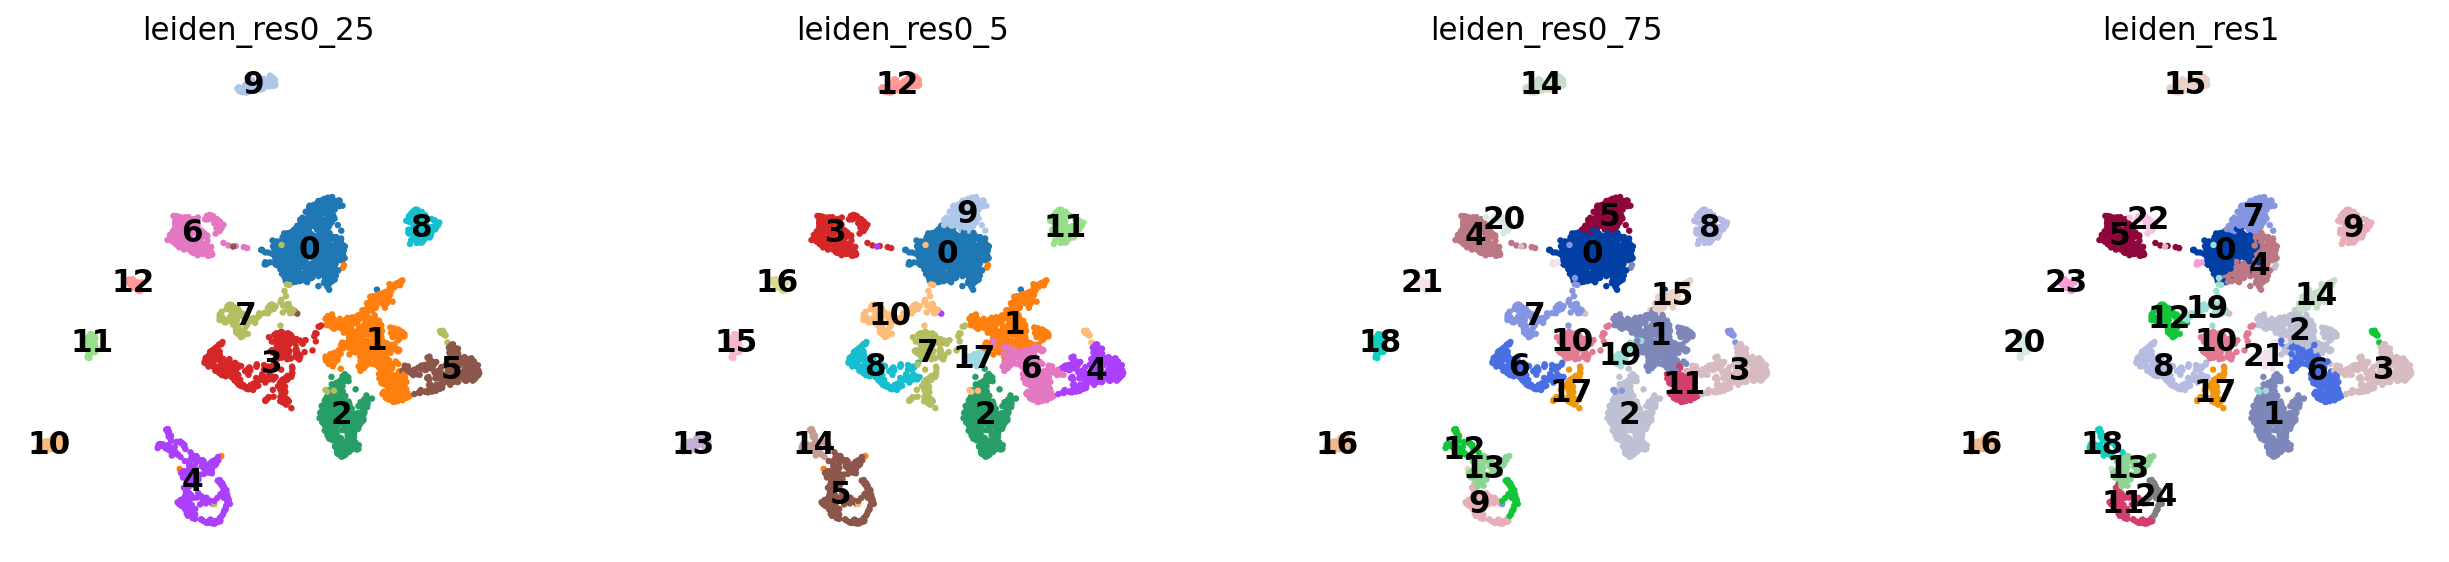

In [6]:
# visualize the different clustering results
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res0_75", "leiden_res1"],
    legend_loc="on data",
)

In [7]:
# save the dataset to file
anndata.settings.allow_write_nullable_strings = True
adata.write("clustering.h5ad.gz", compression='gzip')